<a href="https://colab.research.google.com/github/norrismeg/odw/blob/main/Data_Challenge_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Challenge 4 (8 points) -- Advanced**

Use the data file challenge3.gwf with channels H1:CHALLENGE3 and L1:CHALLENGE3.

These are real LIGO data from O2, though we've adjusted the time labels and added some simulated signals.

Any simulated signals have been added to both the H1 and L1 data

All simulated signals have spin = 0 and m1 = m2, with m1 somewhere in the range 10-50 solar masses
1. Identify as many signals as you can. Watch out! These are real data, and so glitches may be present. Any correct detection is +1 point but any false alarms will count -1 point against your score. For each signal you find, list:

  * The merger time
  * The SNR
  * Your estimate of the component masses

2. Identify as many glitches as you can. Make a spectrogram of each one.

3. For each simulated BBH you found, use bilby to compute a posterior distribution for the mass. You can fix the spin and mass ratio to make this run faster.

In [4]:
# Those 2 lines are just to avoid some harmless warnings when importing packages
import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")

In [5]:
! pip install -q pycbc
! pip install -q gwpy
! pip install -U -q bilby==2.4.0 matplotlib==3.10.0 dynesty==2.1.5 corner==2.2.3 gwpy==3.0.12 lalsuite==7.25 scipy==1.12.0
# -- Click "restart runtime" in the runtime menu

In [6]:
# -- download data
! wget https://dcc.ligo.org/public/0187/G2300818/001/challenge3.gwf

# -- for gwpy
from gwpy.timeseries import TimeSeries,TimeSeriesDict
#gwpy_strain = TimeSeriesDict.read('challenge3.gwf', ["H1:CHALLENGE3","L1:CHALLENGE3"])
#gwpy_strain_L1 = TimeSeries.read('challenge3.gwf', channel="L1:CHALLENGE3")

# -- for pycbc
from pycbc import frame
#pycbc_strain = frame.read_frame('challenge3.gwf', ['H1:CHALLENGE3','L1:CHALLENGE3'])
#pycbc_strain_L1 = frame.read_frame('challenge3.gwf', 'L1:CHALLENGE3')

import bilby

# Make bilby more terse
bilby.core.utils.log.setup_logger(log_level='WARNING')

--2025-06-10 13:53:11--  https://dcc.ligo.org/public/0187/G2300818/001/challenge3.gwf
Resolving dcc.ligo.org (dcc.ligo.org)... 131.215.125.133
Connecting to dcc.ligo.org (dcc.ligo.org)|131.215.125.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 256814830 (245M)
Saving to: ‘challenge3.gwf’

challenge3.gwf      100%[===================>] 244.92M   103MB/s    in 2.4s    

2025-06-10 13:53:13 (103 MB/s) - ‘challenge3.gwf’ saved [256814830/256814830]



1. Identify as many signals as you can. Watch out! These are real data, and so glitches may be present. Any correct detection is +1 point but any false alarms will count -1 point against your score. For each signal you find, list:

  * The merger time
  * The SNR
  * Your estimate of the component masses

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from pycbc.waveform import get_td_waveform
from pycbc.filter import matched_filter, resample_to_delta_t, highpass
from pycbc.psd import interpolate, inverse_spectrum_truncation

/home/paulalexander.baynard/.conda/envs/odw-py311/lib/python3.11/site-packages/pykerr/qnm.py:2: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  import pkg_resources
/home/paulalexander.baynard/.conda/envs/odw-py311/lib/python3.11/site-packages/pkg_resources/__init__.py:3147: DeprecationWarning: Deprecated call to `pkg_resources.declare_namespace('ligo')`.
Implementing implicit namespace packages (as specified in PEP 420) is preferred to `pkg_resources.declare_namespace`. See https://setuptools.pypa.io/en/latest/references/keywords.html#keyword-namespace-packages
  declare_namespace(pkg)


False
H1
False
L1


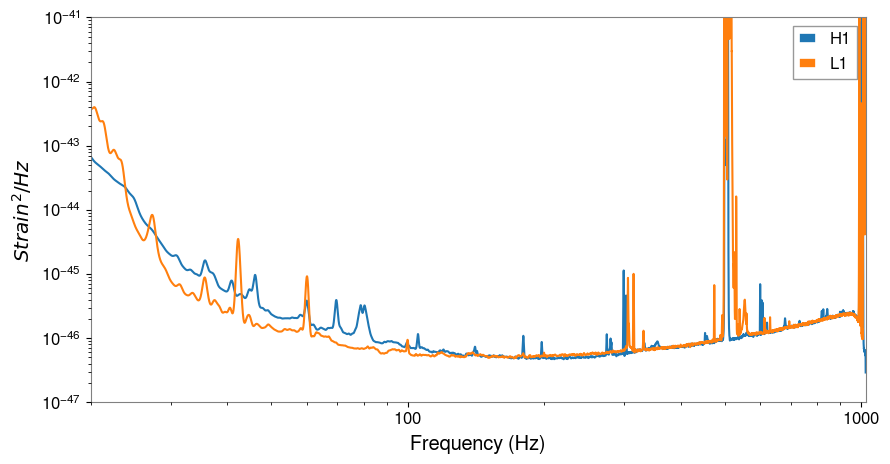

In [8]:
ifos = ['H1','L1']
pycbc_strain = {}
data = {}
psd = {}

plt.figure(figsize=[10, 5])


for ifo in ifos:
    # Read in and precondition the data
    channel = (ifo)+':CHALLENGE3'
    pycbc_strain[ifo] = frame.read_frame('challenge3.gwf', channel)

for ifo, ts in pycbc_strain.items():
    print(isinstance(ts,TimeSeries))
    print(ifo)
    t_s = highpass(ts, 15)
    data[ifo] = resample_to_delta_t(t_s, 1.0/2048).crop(2, 2)

    # Estimate the power spectral density of the data
    # This chooses to use 2s samples in the PSD estimate.
    p = data[ifo].psd(2)
    p = interpolate(p, data[ifo].delta_f)
    p = inverse_spectrum_truncation(p, int(2 * data[ifo].sample_rate), low_frequency_cutoff=15.0)
    psd[ifo] = p

    plt.plot(psd[ifo].sample_frequencies, psd[ifo], label=ifo)

plt.yscale('log')
plt.xscale('log')
plt.ylim(1e-47, 1e-41)
plt.xlim(20, 1024)
plt.ylabel('$Strain^2 / Hz$')
plt.xlabel('Frequency (Hz)')
plt.grid()
plt.legend()
plt.show()

In [9]:
from pycbc.detector import Detector

# Calculate the time of flight between each LIGO observatory
d = Detector("L1")
tof = d.light_travel_time_to_detector(Detector("H1"))
print(tof)


0.010012846152223925


26682
26682
13.0283203125


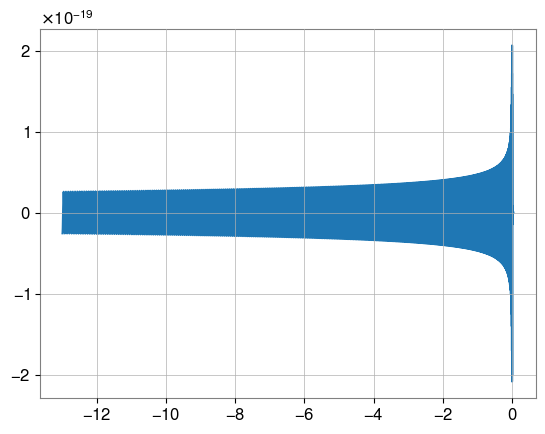

8380416
4092.0


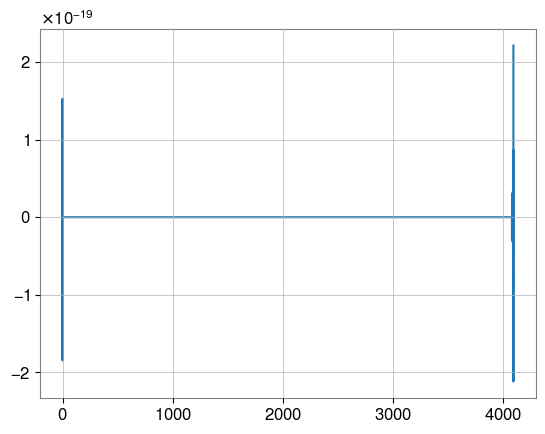

In [10]:
hp, hc = get_td_waveform(approximant="SEOBNRv4_opt",
                            mass1=10,
                            mass2=10,
                            delta_t=data['H1'].delta_t,
                            f_lower=15)
print(len(hp))
print(len(hc))
print(hp.duration)
plt.plot(hp.sample_times, hp)
plt.show()
hp.resize(len(data['H1']))
print(len(hp))
template = hp.cyclic_time_shift(hp.start_time)
print(template.duration)

plt.plot(template.sample_times, template)

8380416
[10]


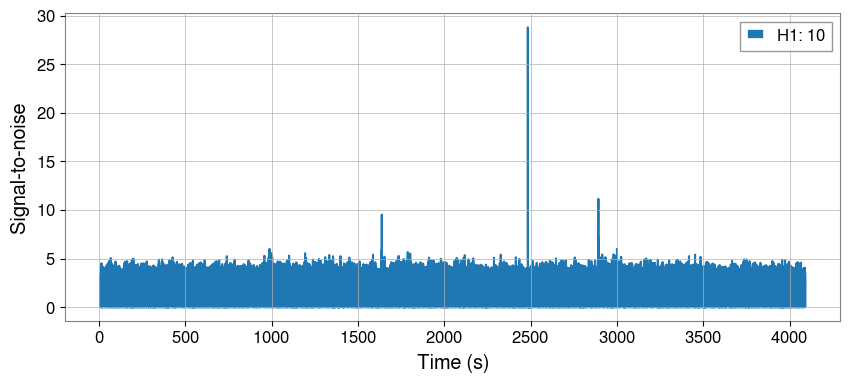

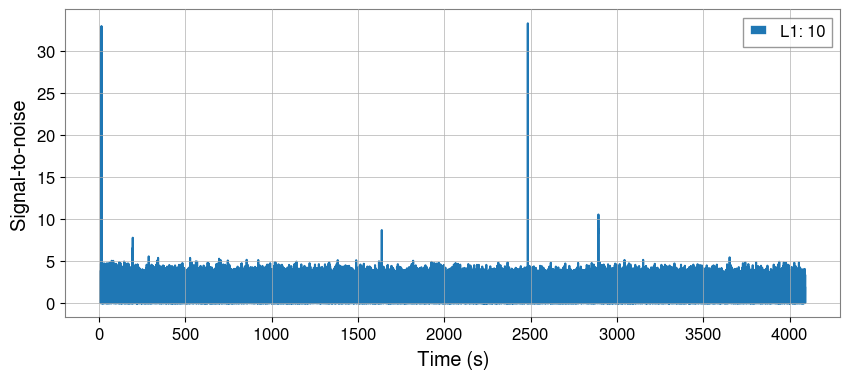

H1 peak: 4.496011445804205 4 False
L1 peak: 32.97812676345438 4 False
H1 peak: 3.9949930339000916 5 False
L1 peak: 7.08195506215225 5 False
H1 peak: 5.072112853327153 58 False
L1 peak: 3.406818163600136 58 False
H1 peak: 4.318241330943307 64 False
L1 peak: 5.0636753674434525 64 False
H1 peak: 3.288850931372016 72 False
L1 peak: 5.053805566419155 72 False
H1 peak: 3.7212999919440337 186 False
L1 peak: 7.803926855868498 186 False
H1 peak: 5.015752729454966 189 False
L1 peak: 4.182681744210207 189 False
H1 peak: 3.502643162703132 278 False
L1 peak: 5.584913729574164 278 False
H1 peak: 3.8307735042333078 328 False
L1 peak: 5.102890501635366 328 False
H1 peak: 3.809344872471508 332 True
L1 peak: 5.408724158179301 332 True
H1 peak: 5.138678761978714 417 True
L1 peak: 3.2094595167644595 417 True
H1 peak: 3.720442608940558 518 False
L1 peak: 5.404302110356003 518 False
H1 peak: 4.00371462391877 685 False
L1 peak: 5.306117408642537 685 False
H1 peak: 3.717426883178991 694 False
L1 peak: 5.16037

In [11]:
m_range = [m for m in range(10,15,5)]
data_length = len(data['H1'])
print(data_length)

signals = [] # List of possible signals
glitches = [] # List of likely glitches

print(m_range)

threshold = 5 # snr threshold

for mass in m_range:
  hp, hc = get_td_waveform(approximant="SEOBNRv4_opt",
                            mass1=mass,
                            mass2=mass,
                            delta_t=data['H1'].delta_t,
                            f_lower=15)
  hp.resize(len(data['H1'])) # why resize it to be the length of the data?
  template = hp.cyclic_time_shift(hp.start_time) # what time is it being shifted to?
  peaks_H1 = []
  peaks_L1 = []

  for ifo, conditioned in data.items():
    snr = matched_filter(template, conditioned, psd=psd[ifo], low_frequency_cutoff=15.0)
    # Does the matched_filter function slide the template along the data, or does it just compare the two time series statically?

    # Remove time corrupted by the template filter and the psd filter
    # We remove 4 seconds at the beginning and end for the PSD filtering
    # And we remove 4 additional seconds at the beginning to account for
    # the template length (this is somewhat generous for
    # so short a template). A longer signal such as from a BNS, would
    # require much more padding at the beginning of the vector.
    snr = snr.crop(4 + 4, 4)

    plt.figure(figsize=[10, 4])
    plt.plot(snr.sample_times, abs(snr), label=ifo+': '+str(mass))
    plt.legend()
    plt.ylabel('Signal-to-noise')
    plt.xlabel('Time (s)')
    plt.show()

    #print(np.extract(abs(snr)>8, abs(snr)))

    for i in range(int(len(snr)/2048)):
      snr_seg = snr[2048*i:2048*(i+1)]
      #    time_seg = snr.sample_times[2048*i:2048*(i+1)]
      peak = abs(snr_seg).numpy().argmax()
      snrp = snr_seg[peak]
      time = snr_seg.sample_times[peak]
      #    print(abs(snrp))
      #    if abs(snrp) > threshold:
      if ifo == 'H1':
        peaks_H1.append([mass, time, abs(snrp)])
      elif ifo == 'L1':
        peaks_L1.append([mass, time, abs(snrp)])
      else: print('error')

  times_H1 = [b for a,b,c in peaks_H1]
  times_L1 = [b for a,b,c in peaks_L1]

  coins = np.isclose(times_H1, times_L1, atol = 15e-3)
  for i, coin in enumerate(coins):
    if peaks_H1[i][2] > threshold or peaks_L1[i][2] > threshold:
      print('H1 peak:', peaks_H1[i][2], i, coin)
      print('L1 peak:', peaks_L1[i][2], i, coin)
      if coin is True:
        signals.append(times_H1[i])
      else: glitches.append(times_H1[i])
  print(coins)

  print(peaks_H1)
  print(peaks_L1)

print(signals)
print(glitches)

    #peak = abs(snr).numpy().argmax()
    #snrp = snr[peak]
    #time = snr.sample_times[peak]

  # If SNR > threshold (10?) and signal occurs in both detectors within 50 ms using the same template, add time, snrp, and template mass to the list of signals
  # If SNR > threshold (10?) and signal only occurs in one detector, add time, snrp, detector, and template mass to the list of glitches

  #print("Mass: {}. We found a signal at {}s with SNR {}".format(mass, time, abs(snrp)))

  # gwpy TimeSeries methods: correlate, find_gates, inject
  # numpy.extract

In [12]:
#for coin in coins:
  #if coin == True:
    #print(coin)

In [13]:
np.where(coins==True)[0]

array([  74,   99,  107, ..., 4047, 4068, 4071])

In [14]:
len(np.where(coins==True)[0])

296

In [15]:
array = [[1,3],[2,3],[3,9],[4,4],[5,3],[6,3],[7,15],[8,4],[9,4],[10,3]]

snr_peaks = np.where(abs(snr)>8)[0] # need index because np.where returns a tuple
print(snr_peaks)

[  10200   10203   10204   10205   10206   10207   10208   10209
   10210   10211   10212   10213   10214   10215   10216   10217
   10218   10219   10220   10221   10222   10223   10224   10225
   10226   10227   10228   10229   10230   10231   10232   10233
   10234   10235   10237   10238   10239 3334508 3334509 3334510
 3334511 3334512 3334513 3334673 3334674 3334675 3334676 3334677
 5066666 5066667 5066668 5066669 5066670 5066671 5066672 5066673
 5066674 5066675 5066676 5066677 5066678 5066679 5066680 5066681
 5066682 5066683 5066684 5066685 5066686 5066687 5066688 5066689
 5066690 5066691 5066692 5066693 5066694 5066695 5066696 5066697
 5066698 5066699 5066700 5066701 5066702 5066703 5066704 5066705
 5903795 5903796 5903797 5903807 5903808 5903809 5903810 5903811
 5903812 5903813 5903921 5903922 5903923 5903924 5903925 5903926
 5903927 5903928 5903929 5903930 5903931 5903932 5903933 5903934
 5903935 5903936 5903937 5903938 5903939 5903940 5903941 5903942
 5903943 5903944 5903945 

In [22]:
candidates = []

for i, index in enumerate(snr_peaks):
  print(i)
  #print(i)
  snrp = abs(snr)[index]
  #print(snrp)
  time = snr.sample_times[index]
  #print(time)
  candidates.append(np.array([time,abs(snrp)]))
  #print("Mass: {}. We found a signal at {}s with SNR {}".format(mass, time, abs(snrp)))

print(candidates)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
[array([14.98046875,  8.6567097 ]), array([14.98193359,  8.71643522]), array([14.98242188,  9.89463078]), array([14.98291016,  9.19197785]), array([14.98339844,  8.61871544]), array([14.98388672, 11.15966835]), array([14.984375  , 13.69316789]), array([14.98486328, 13.20362755]), array([14.98535156, 10.19565475]), array([14.98583984, 12.67653318]), array([14.98632812, 18.71960736]), array([14.98681641, 21.3408401 ]), array([14.98730469, 16.46869553]), array([14.98779297, 10.46499366]), array([14.98828125,

In [23]:
np.array(candidates)

array([[  14.98046875,    8.6567097 ],
       [  14.98193359,    8.71643522],
       [  14.98242188,    9.89463078],
       ...,
       [2892.80908203,    8.83984472],
       [2892.80957031,    8.81348715],
       [2892.81005859,    8.43045079]])

2. Identify as many glitches as you can. Make a spectrogram of each one.

3. For each simulated BBH you found, use bilby to compute a posterior distribution for the mass. You can fix the spin and mass ratio to make this run faster.

In [18]:
sampling_rate = 2048  # needs to be high enough for the signals found in steps above
duration = 8  # needs to be long enough for the signals found in steps above
start_time = 100  # needs to be set so that the segment defined by [start_time,start_time+duration] contains the signal

interferometers = bilby.gw.detector.InterferometerList([])
for ifo_name in ['H1', 'L1']:
    ifo = bilby.gw.detector.get_empty_interferometer(ifo_name)
    ifo.set_strain_data_from_frame_file('challenge3.gwf', sampling_rate, duration, start_time=start_time, channel=f'{ifo_name}:CHALLENGE3')
    interferometers.append(ifo)

In [19]:
print(interferometers)

[Interferometer(name='H1', power_spectral_density=PowerSpectralDensity(psd_file='None', asd_file='/home/paulalexander.baynard/.conda/envs/odw-py311/lib/python3.11/site-packages/bilby/gw/detector/noise_curves/aLIGO_O4_high_asd.txt'), minimum_frequency=20.0, maximum_frequency=1024.0, length=4.0, latitude=46.45514666666667, longitude=-119.4076571388889, elevation=142.554, xarm_azimuth=125.9994, yarm_azimuth=215.9994, xarm_tilt=-0.0006195, yarm_tilt=1.25e-05), Interferometer(name='L1', power_spectral_density=PowerSpectralDensity(psd_file='None', asd_file='/home/paulalexander.baynard/.conda/envs/odw-py311/lib/python3.11/site-packages/bilby/gw/detector/noise_curves/aLIGO_O4_high_asd.txt'), minimum_frequency=20.0, maximum_frequency=1024.0, length=4.0, latitude=30.562894333333332, longitude=-90.77424038888887, elevation=-6.574, xarm_azimuth=197.7165, yarm_azimuth=287.7165, xarm_tilt=-0.0003121, yarm_tilt=-0.0006107)]


In [20]:
chirp_mass_min = 10/(2**(1/5))
chirp_mass_max = 50/(2**(1/5))
print(chirp_mass_min,chirp_mass_max)

8.705505632961241 43.527528164806206


In [21]:
chirp_mass_min = 10/(2**(1/5))
chirp_mass_max = 50/(2**(1/5))
print(chirp_mass_min,chirp_mass_max)

prior = bilby.core.prior.PriorDict()
prior['chirp_mass'] = Uniform(name='chirp_mass', minimum=chirp_mass_min,maximum=chirp_mass_max)
prior['mass_ratio'] = 1.0
prior['phase'] = Uniform(name="phase", minimum=0, maximum=2*np.pi)
prior['geocent_time'] = Uniform(name="geocent_time", minimum=time_of_event-0.1, maximum=time_of_event+0.1)
prior['a_1'] =  0.0
prior['a_2'] =  0.0
prior['tilt_1'] =  0.0
prior['tilt_2'] =  0.0
prior['phi_12'] =  0.0
prior['phi_jl'] =  0.0
#prior['dec'] =  -1.2232
#prior['ra'] =  2.19432
#prior['theta_jn'] =  1.89694
#prior['psi'] =  0.532268
prior['luminosity_distance'] = PowerLaw(alpha=2, name='luminosity_distance', minimum=50, maximum=2000, unit='Mpc', latex_label='$d_L$')


8.705505632961241 43.527528164806206


NameError: name 'Uniform' is not defined